# Apriori Algorithm Implementation

# IMPORTING REQUIRED LIBRARIES 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# IMPORTING DATASET

In [2]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\Tutorial Datasets\Groceries_dataset.csv")
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [3]:
df.shape

(38765, 3)

In [4]:
df.info()# Displays the structure of the dataset (column names, data types, sample values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [5]:
df.describe()# Generates descriptive statistics

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


# DATA CLEANING AND EXPLORATION

In [6]:
df.head

<bound method NDFrame.head of        Member_number        Date        itemDescription
0               1808  21-07-2015         tropical fruit
1               2552  05-01-2015             whole milk
2               2300  19-09-2015              pip fruit
3               1187  12-12-2015       other vegetables
4               3037  01-02-2015             whole milk
...              ...         ...                    ...
38760           4471  08-10-2014          sliced cheese
38761           2022  23-02-2014                  candy
38762           1097  16-04-2014               cake bar
38763           1510  03-12-2014  fruit/vegetable juice
38764           1521  26-12-2014               cat food

[38765 rows x 3 columns]>

In [7]:
                    #CHECKING FOR NA VALUES
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [8]:
                    #CHECKING DUPLICATES
df.duplicated().sum()

np.int64(759)

In [9]:
                    #Group all the items that were bought together by the same customer on the same date
itemList = df.groupby(['Member_number', 'Date'])['itemDescription'] \
             .apply(lambda x: ', '.join(x)) \
             .reset_index(name='items')

itemList.head(15)# Groups data by customer (Member_number) and transaction date
                # Combines all items bought in one transaction into a single comma-separated string
                # Resets index and renames the new column as 'items'

,Member_number,Date,items
0,1000,15-03-2015,"sausage, whole milk, semi-finished bread, yogurt"
1,1000,24-06-2014,"whole milk, pastry, salty snack"
2,1000,24-07-2015,"canned beer, misc. beverages"
3,1000,25-11-2015,"sausage, hygiene articles"
4,1000,27-05-2015,"soda, pickled vegetables"
5,1001,02-05-2015,"frankfurter, curd"
6,1001,07-02-2014,"sausage, whole milk, rolls/buns"
7,1001,12-12-2014,"whole milk, soda"
8,1001,14-04-2015,"beef, white bread"
9,1001,20-01-2015,"frankfurter, soda, whipped/sour cream"


In [10]:
df['itemDescription'].value_counts().head(10)# Displays top 10 most frequently bought items

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

In [11]:
df['Member_number'].nunique()

3898

In [12]:
df['Date'].nunique()

728

# EXPLORATORY DATA ANALYSIS (EDA)

In [13]:
                            #Top Purchased Items
top_items = df['itemDescription'].value_counts().head(15)
top_items

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
pastry               785
pip fruit            744
shopping bags        731
canned beer          717
bottled beer         687
Name: count, dtype: int64

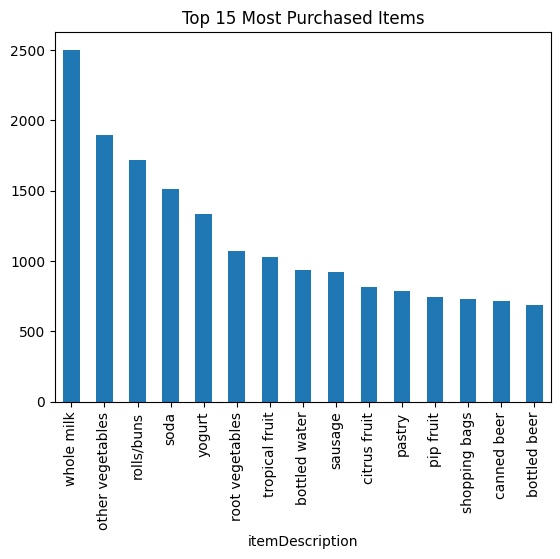

In [14]:
# TOP 15 PRODUCTS
top_items = df['itemDescription'].value_counts().head(15)
top_items.plot(kind='bar')
plt.title("Top 15 Most Purchased Items")
plt.show()

In [15]:
                                #Least Purchased Items
least_items = df['itemDescription'].value_counts().tail(15)
least_items

itemDescription
frozen fruits            11
organic products         10
liqueur                   9
hair spray                9
decalcifier               9
whisky                    8
salad dressing            6
make up remover           5
toilet cleaner            5
frozen chicken            5
rubbing alcohol           5
bags                      4
baby cosmetics            3
kitchen utensil           1
preservation products     1
Name: count, dtype: int64

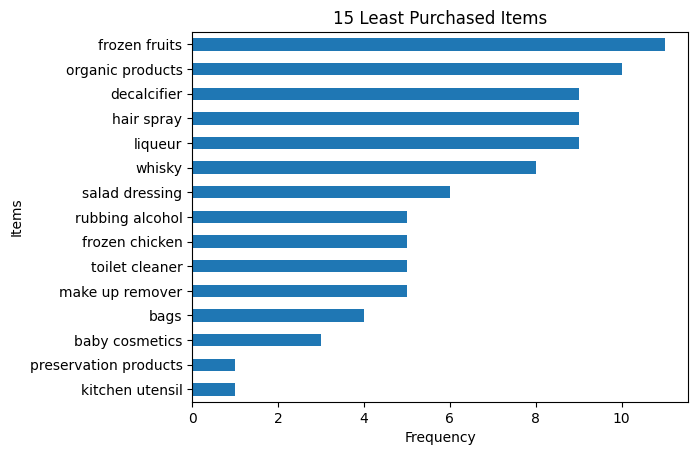

In [16]:
                            # Least purchased items
least_items = df['itemDescription'].value_counts().tail(15)
plt.figure()
least_items.sort_values().plot(kind='barh')  # horizontal bar chart
plt.title("15 Least Purchased Items")
plt.xlabel("Frequency")
plt.ylabel("Items")
plt.show()

In [17]:
                    #CUSTOMER BEHAVIOR ANALYSIS 
                    #Transactions per Customer
transactions_per_customer = df.groupby('Member_number')['Date'].nunique()# Counts number of unique transaction dates per customer
transactions_per_customer.describe()# Provides statistical summary of transactions per customer

count    3898.000000
mean        3.838635
std         1.883678
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max        11.000000
Name: Date, dtype: float64

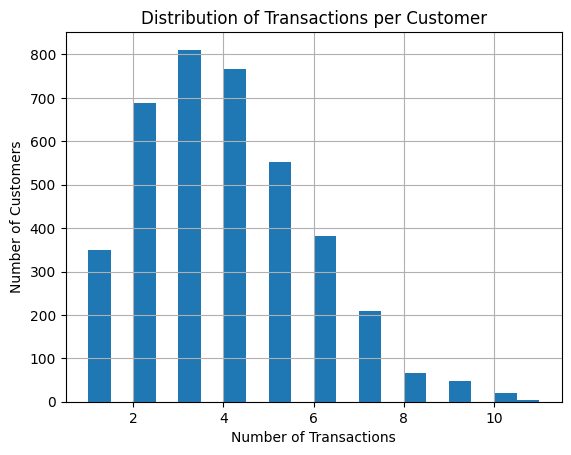

In [18]:
                     # Transactions per customer
transactions_per_customer = df.groupby('Member_number')['Date'].nunique()
plt.figure()
transactions_per_customer.hist(bins=20)
plt.title("Distribution of Transactions per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.show()

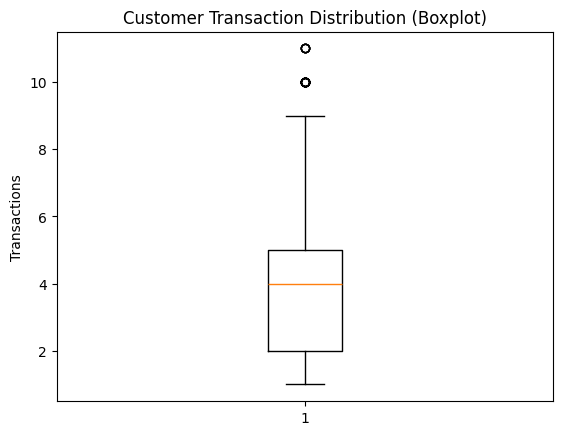

In [19]:
                #Customer Transaction Distribution 
plt.figure()
plt.boxplot(transactions_per_customer)
plt.title("Customer Transaction Distribution (Boxplot)")
plt.ylabel("Transactions")
plt.show()

In [20]:
                        #Top Customers (Most Active)
top_customers = transactions_per_customer.sort_values(ascending=False).head(10)
top_customers

Member_number
2271    11
1379    11
4338    11
3737    11
2193    11
3593    10
1052    10
2625    10
3484    10
4217    10
Name: Date, dtype: int64

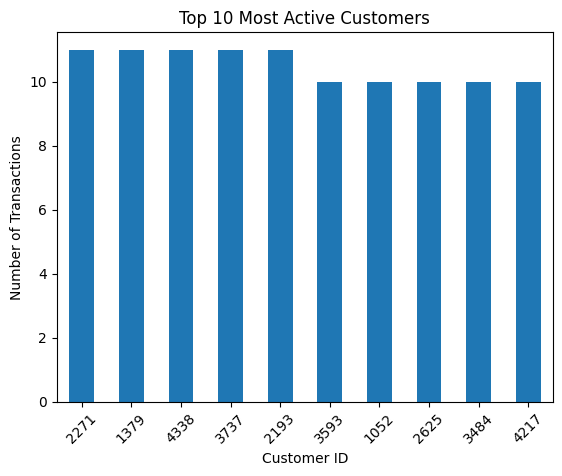

In [21]:
                            #TOP 10 MOST ACTIVE CUSTOMERS
top_customers = transactions_per_customer.sort_values(ascending=False).head(10)
plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Most Active Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [22]:
                        #CUSTOMER SEGMENTATION
customer_total_items = df.groupby('Member_number')['itemDescription'].count()
customer_total_items.describe()

count    3898.000000
mean        9.944844
std         5.310796
min         2.000000
25%         6.000000
50%         9.000000
75%        13.000000
max        36.000000
Name: itemDescription, dtype: float64

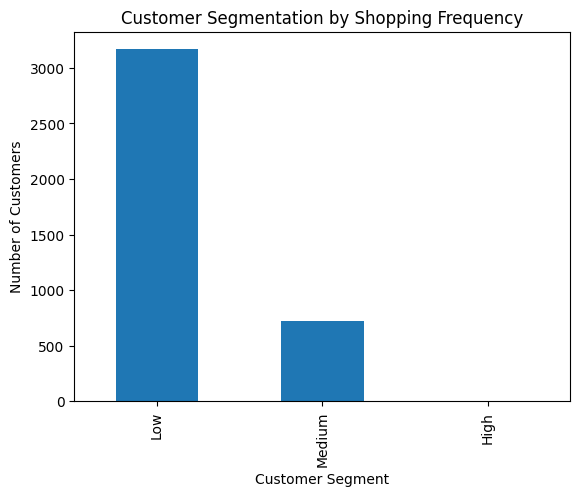

In [23]:
                            # CUSTOMER SEGMENTATION
customer_segments = pd.cut(
    transactions_per_customer,
    bins=[0, 5, 10, transactions_per_customer.max()],
    labels=['Low', 'Medium', 'High']# Segments customers into categories:
                                    # Low (0–5), Medium (6–10), High (>10 transactions)
)
segment_counts = customer_segments.value_counts()# Counts number of customers in each segment
plt.figure()
segment_counts.plot(kind='bar')
plt.title("Customer Segmentation by Shopping Frequency")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [24]:
                            #BASKET ANALYSIS
                            #Basket Size (Items per Transaction)
basket_size = df.groupby(['Member_number', 'Date'])['itemDescription'].count()
basket_size.describe()

count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: itemDescription, dtype: float64

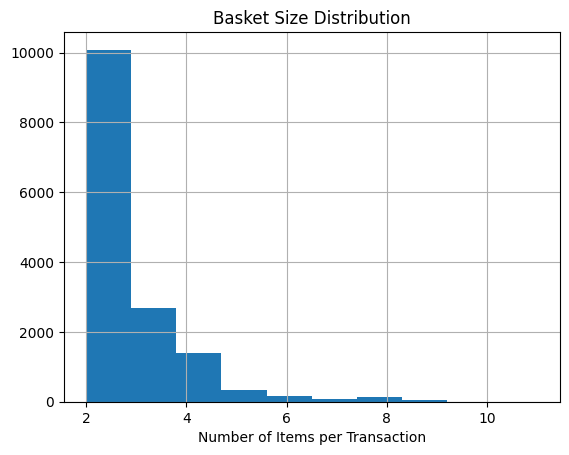

In [25]:
basket_size.hist()
plt.title("Basket Size Distribution")
plt.xlabel("Number of Items per Transaction")
plt.show()

# DATA TRANSFORMATION

In [26]:
                #converting raw data → transaction format
                #Create Transactions
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)
transactions = transactions.tolist()
transactions[:15]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['beef', 'white bread'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['sausage', 'rolls/buns']]

In [27]:
            #Convert transaction data to one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
print("One-hot encoded data:")
print(df.head)

One-hot encoded data:
<bound method NDFrame.head of        Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                      False     False             False             False   
1                      False     False             False             False   
2                      False     False             False             False   
3                      False     False             False             False   
4                      False     False             False             False   
...                      ...       ...               ...               ...   
14958                  False     False             False             False   
14959                  False     False             False             False   
14960                  False     False             False             False   
14961                  False     False             False             False   
14962                  False     False             False             False   

       baby

# DATA MODELLING

# APRIORI ALGORITHM

In [28]:
from mlxtend.frequent_patterns import apriori, association_rule
# Step 1: Generate frequent itemsets
frequent_itemsets = apriori(df, min_support=0.001, use_colnames=True)
# Step 2: Generate association rules
basket_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)
# Step 3: View rules
print(basket_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

ImportError: cannot import name 'association_rule' from 'mlxtend.frequent_patterns' (c:\Users\hp\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\__init__.py)

In [ ]:
print(len(basket_rules))

450


In [ ]:
# Show first few rules
print(basket_rules.head())

  antecedents         consequents  antecedent support  consequent support  \
0  (UHT-milk)     (bottled water)            0.021386            0.060683   
1  (UHT-milk)  (other vegetables)            0.021386            0.122101   
2  (UHT-milk)        (rolls/buns)            0.021386            0.110005   
3  (UHT-milk)           (sausage)            0.021386            0.060349   
4  (UHT-milk)              (soda)            0.021386            0.097106   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.001069    0.050000  0.823954               1.0 -0.000228    0.988755   
1  0.002139    0.100000  0.818993               1.0 -0.000473    0.975443   
2  0.001804    0.084375  0.767013               1.0 -0.000548    0.972009   
3  0.001136    0.053125  0.880298               1.0 -0.000154    0.992371   
4  0.001270    0.059375  0.611444               1.0 -0.000807    0.959887   

   zhangs_metric   jaccard  certainty  kulczynski  
0      -0.179204  0.01

In [ ]:
# Get a quick summary of numeric columns like support, confidence, lift
print(basket_rules.describe())

       antecedent support  consequent support     support  confidence  \
count          450.000000          450.000000  450.000000  450.000000   
mean             0.033725            0.101592    0.002760    0.087591   
std              0.027191            0.033282    0.002267    0.029537   
min              0.005347            0.037626    0.001002    0.050000   
25%              0.015973            0.069572    0.001270    0.063974   
50%              0.023592            0.097106    0.001938    0.081081   
75%              0.043708            0.122101    0.003342    0.104820   
max              0.157923            0.157923    0.014837    0.255814   

             lift  representativity    leverage  conviction  zhangs_metric  \
count  450.000000             450.0  450.000000  450.000000     450.000000   
mean     0.885875               1.0   -0.000565    0.984772      -0.129480   
std      0.205671               0.0    0.000782    0.023205       0.176088   
min      0.519510             

In [ ]:
# Get info about the DataFrame structure
print(basket_rules.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         450 non-null    object 
 1   consequents         450 non-null    object 
 2   antecedent support  450 non-null    float64
 3   consequent support  450 non-null    float64
 4   support             450 non-null    float64
 5   confidence          450 non-null    float64
 6   lift                450 non-null    float64
 7   representativity    450 non-null    float64
 8   leverage            450 non-null    float64
 9   conviction          450 non-null    float64
 10  zhangs_metric       450 non-null    float64
 11  jaccard             450 non-null    float64
 12  certainty           450 non-null    float64
 13  kulczynski          450 non-null    float64
dtypes: float64(12), object(2)
memory usage: 49.3+ KB
None


In [ ]:
# Show rules 1 to 20
print(basket_rules.iloc[0:20])

   antecedents         consequents  antecedent support  consequent support  \
0   (UHT-milk)     (bottled water)            0.021386            0.060683   
1   (UHT-milk)  (other vegetables)            0.021386            0.122101   
2   (UHT-milk)        (rolls/buns)            0.021386            0.110005   
3   (UHT-milk)           (sausage)            0.021386            0.060349   
4   (UHT-milk)              (soda)            0.021386            0.097106   
5   (UHT-milk)    (tropical fruit)            0.021386            0.067767   
6   (UHT-milk)        (whole milk)            0.021386            0.157923   
7   (UHT-milk)            (yogurt)            0.021386            0.085879   
8       (beef)      (citrus fruit)            0.033950            0.053131   
9       (beef)  (other vegetables)            0.033950            0.122101   
10      (beef)              (soda)            0.033950            0.097106   
11      (beef)        (whole milk)            0.033950          

# VISUALIZING THE ASSOCIATION RULES

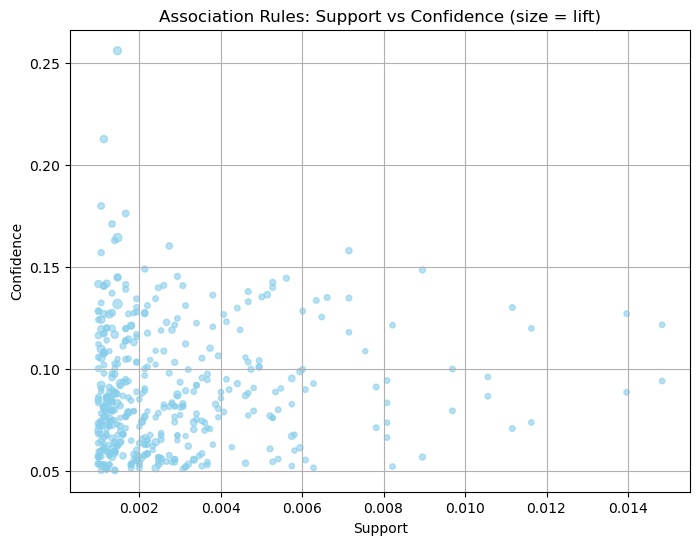

In [ ]:
import matplotlib.pyplot as plt
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(basket_rules['support'], basket_rules['confidence'], 
            s=basket_rules['lift']*20, alpha=0.6, color='skyblue')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (size = lift)')
plt.grid(True)
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_15792\819270094.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lift', y=rule_labels, data=top_lift, palette='viridis')


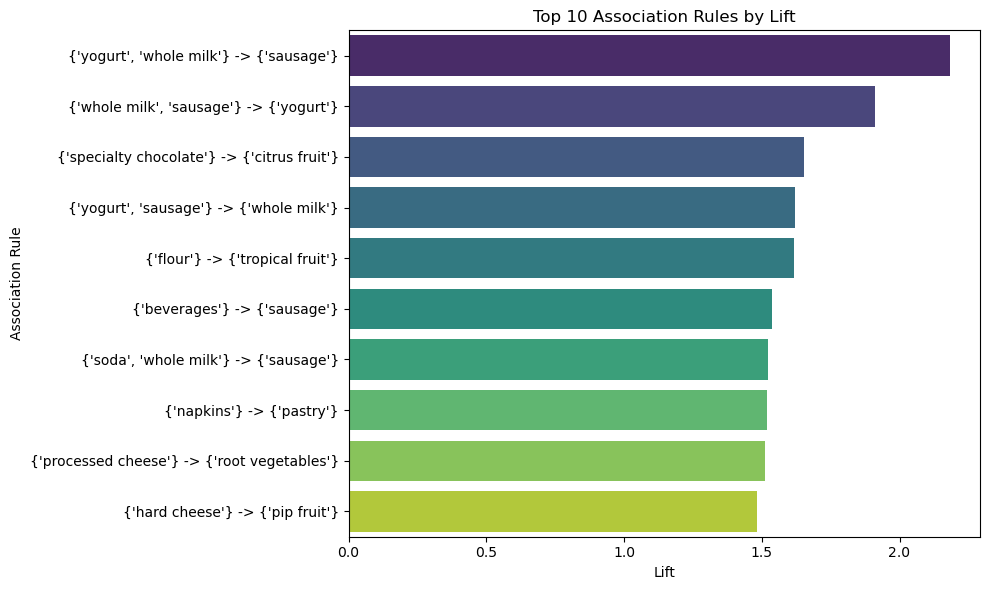

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Sort top 10 rules by lift
top_lift = basket_rules.sort_values('lift', ascending=False).head(10)
# Create readable rule labels
rule_labels = [f"{set(r)} -> {set(c)}" for r, c in zip(top_lift['antecedents'], top_lift['consequents'])]
plt.figure(figsize=(10,6))
sns.barplot(x='lift', y=rule_labels, data=top_lift, palette='viridis')
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top 10 Association Rules by Lift')
plt.tight_layout()
plt.show()

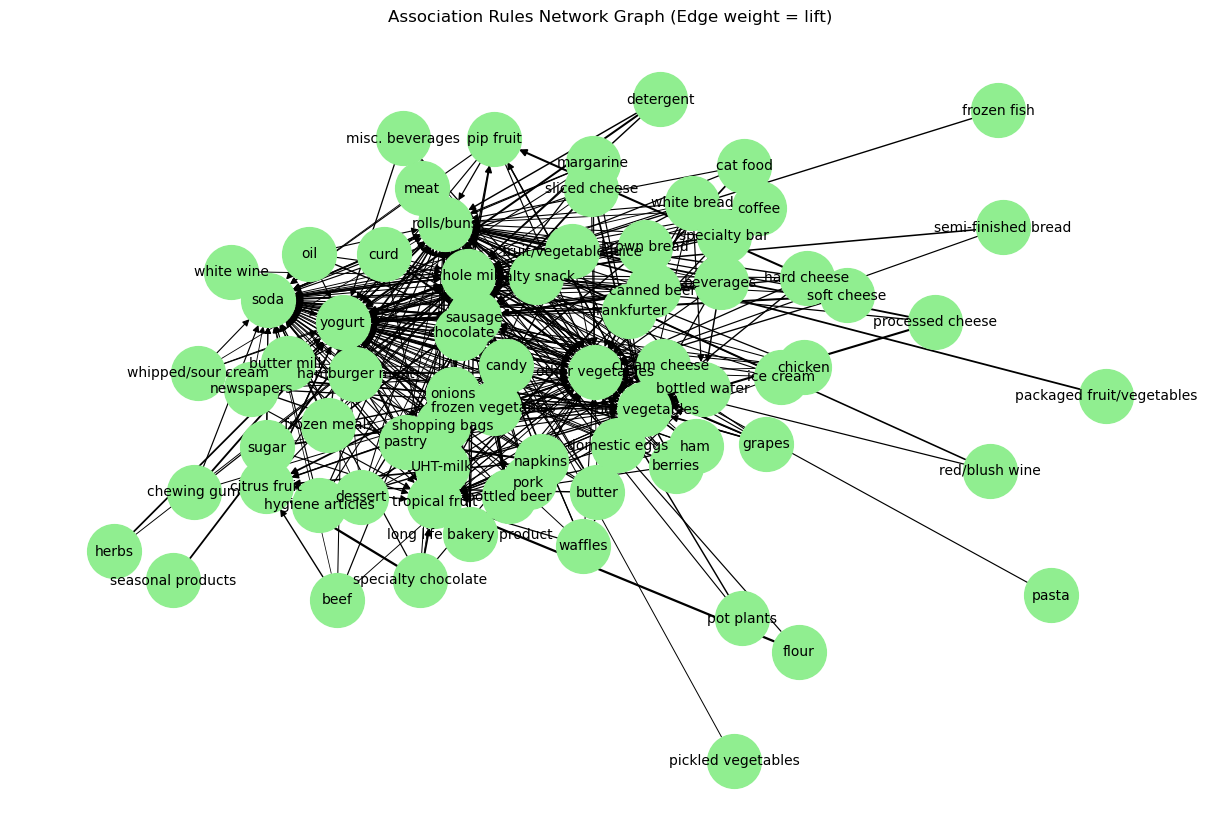

In [ ]:
import networkx as nx
G = nx.DiGraph()
# Add nodes and edges
for i, row in basket_rules.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
nx.draw(G, pos, with_labels=True, node_size=1500, node_color='lightgreen', 
        font_size=10, width=weights)
plt.title("Association Rules Network Graph (Edge weight = lift)")
plt.show()

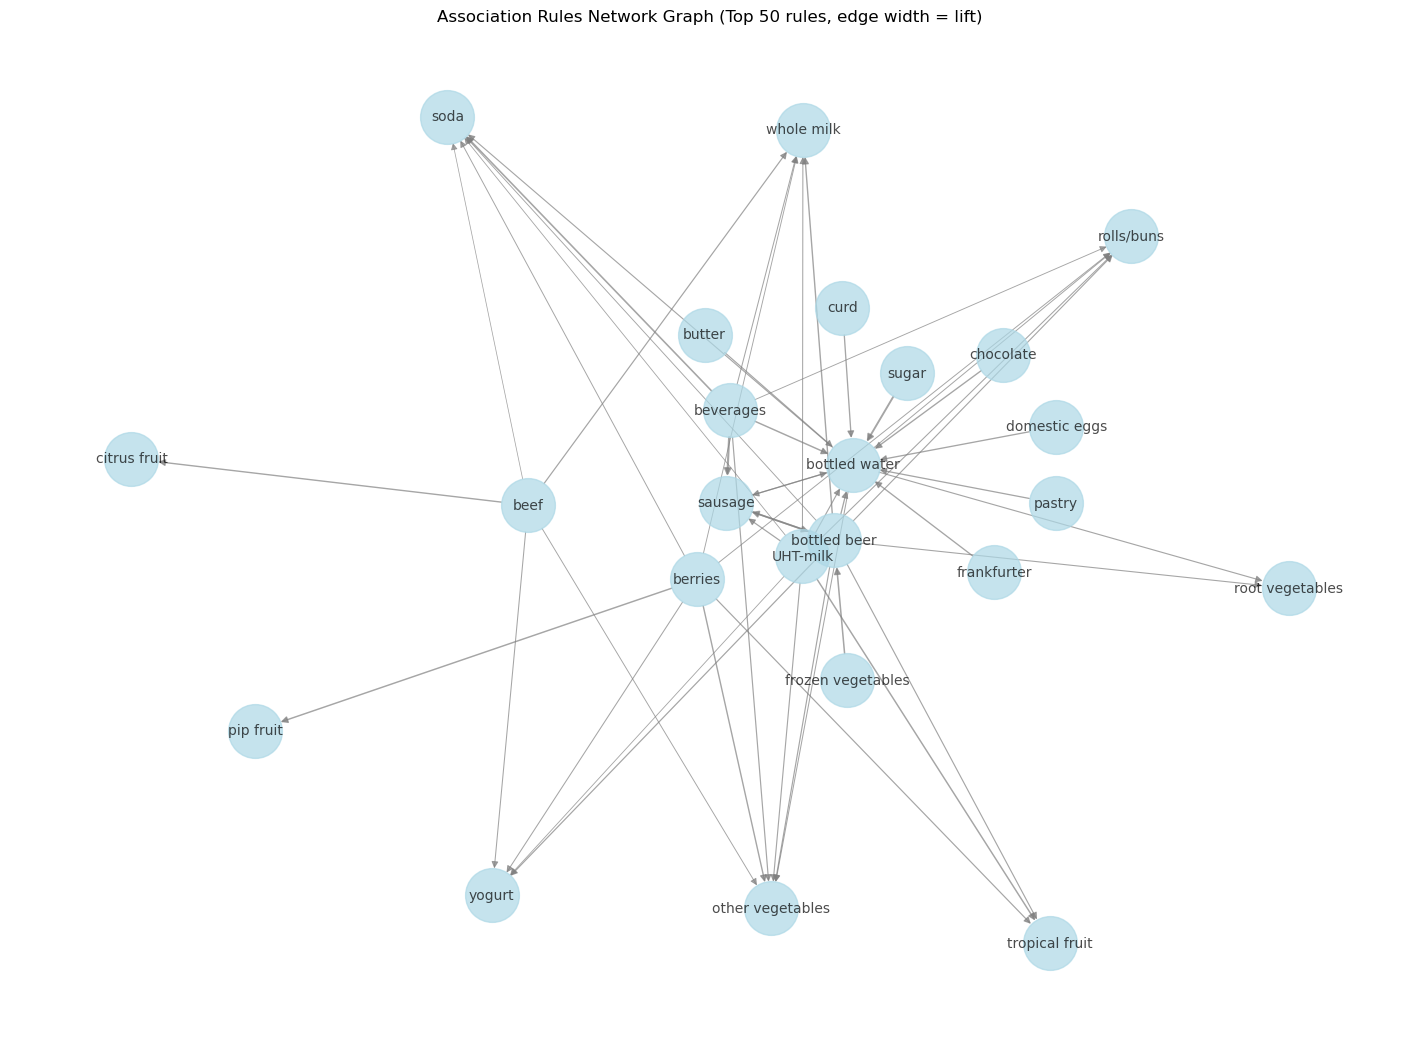

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
# Take the first 50 rules
rules_subset = basket_rules.iloc[0:50]
G = nx.DiGraph()
# Add nodes and edges
for i, row in rules_subset.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            G.add_edge(ant, cons, weight=row['lift'])

plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, k=0.5)  # positions for nodes
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]

nx.draw(G, pos, with_labels=True, node_size=1500, node_color='lightblue', 
        font_size=10, width=weights, edge_color='gray', alpha=0.7)
plt.title("Association Rules Network Graph (Top 50 rules, edge width = lift)")
plt.show()

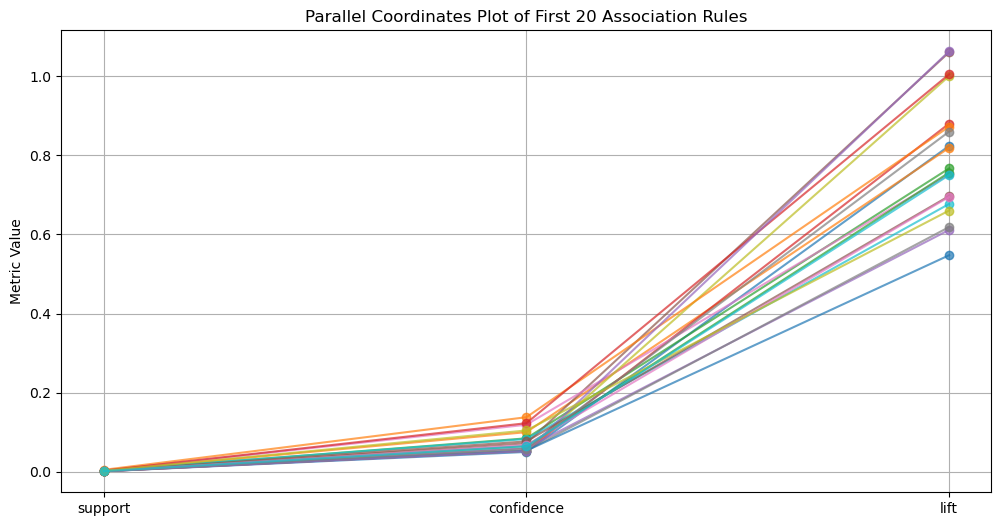

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Take first 20 rules
rules_subset = basket_rules.iloc[0:20].copy()
# Reset index for plotting
rules_subset.reset_index(drop=True, inplace=True)
# Metrics to plot
metrics = ['support', 'confidence', 'lift']
plt.figure(figsize=(12,6))
for i in range(len(rules_subset)):
    plt.plot(metrics, rules_subset.loc[i, metrics], marker='o', alpha=0.7)

plt.title("Parallel Coordinates Plot of First 20 Association Rules")
plt.ylabel("Metric Value")
plt.grid(True)
plt.show()

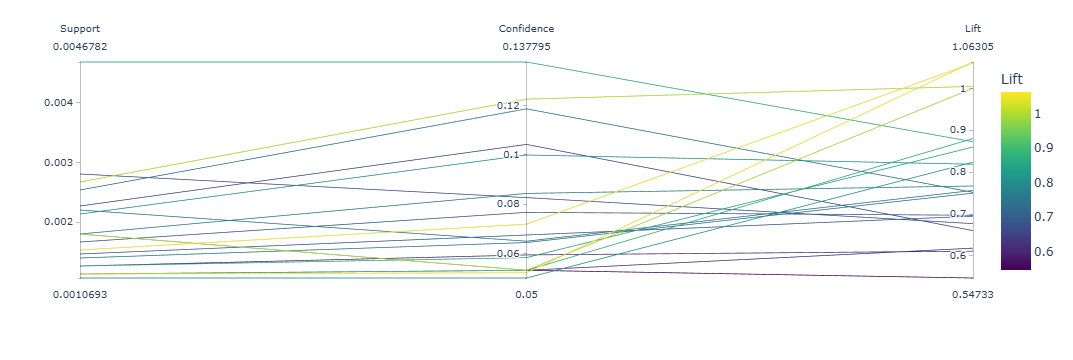

In [ ]:
import plotly.express as px
# For parallel coordinates, convert sets to strings for labels
rules_subset = basket_rules.iloc[0:20].copy()
rules_subset['rule'] = [f"{set(r)} -> {set(c)}" 
                        for r, c in zip(rules_subset['antecedents'], rules_subset['consequents'])]
fig = px.parallel_coordinates(
    rules_subset,
    dimensions=['support', 'confidence', 'lift'],
    color='lift',
    labels={'support':'Support', 'confidence':'Confidence', 'lift':'Lift'},
    color_continuous_scale=px.colors.sequential.Viridis
)
fig.show()

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



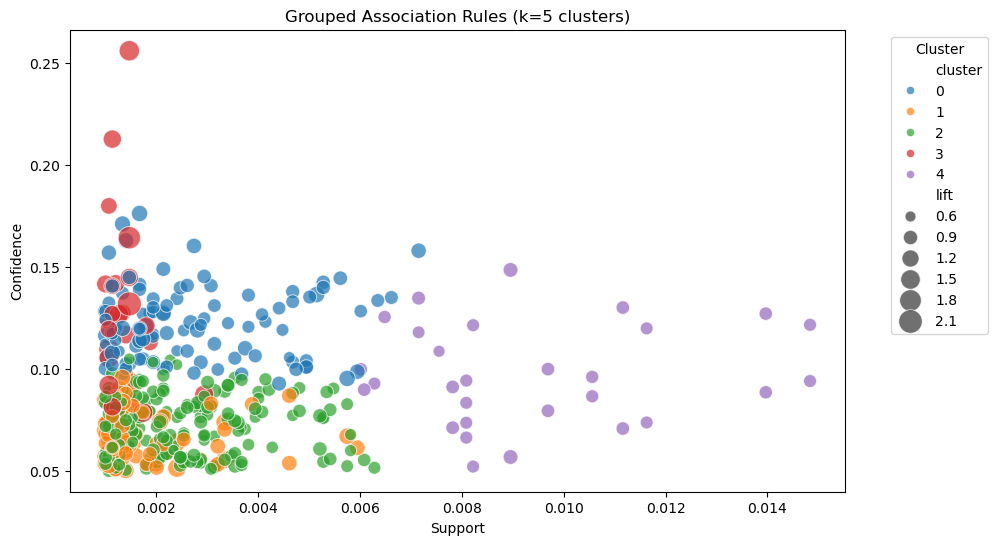

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use support, confidence, lift as features
features = basket_rules[['support', 'confidence', 'lift']]

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Cluster rules (k = 5)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

# Add cluster labels to rules
basket_rules['cluster'] = clusters

# Plot grouped scatter plot (Support vs Confidence, colored by cluster)
plt.figure(figsize=(10,6))
sns.scatterplot(x='support', y='confidence', hue='cluster', 
                palette='tab10', size='lift', sizes=(50,300), data=basket_rules, alpha=0.7)
plt.title(f"Grouped Association Rules (k={k} clusters)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

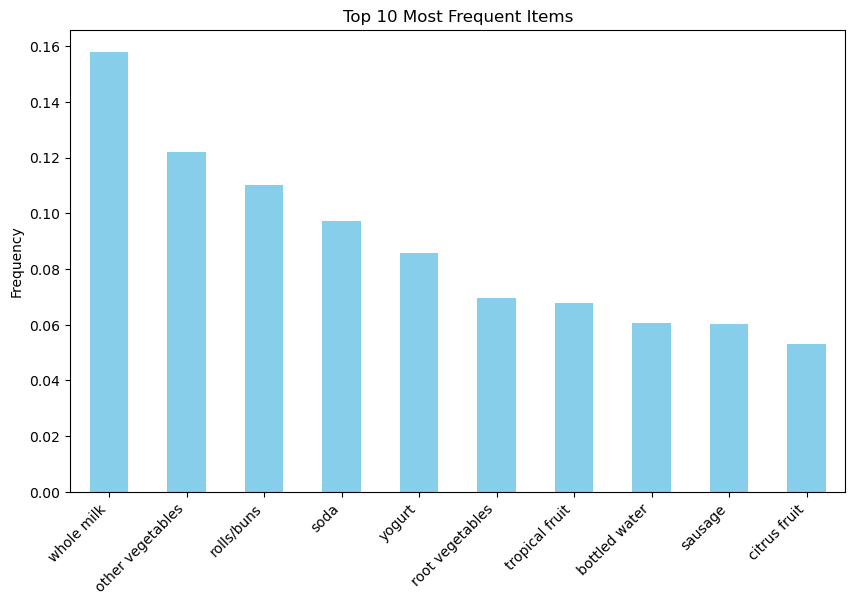

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# If you already have a one-hot encoded transaction DataFrame called 'basket'
# Each column = item, each row = transaction (1 if present, 0 if absent)

# Calculate item frequencies
item_freq = df.sum() / len(df)
item_freq = item_freq.sort_values(ascending=False).head(10)  # Top 10 items

# Plot
plt.figure(figsize=(10,6))
item_freq.plot(kind='bar', color='skyblue')
plt.ylabel('Frequency')
plt.title('Top 10 Most Frequent Items')
plt.xticks(rotation=45, ha='right')
plt.show()